In [1]:
import wbgapi as wb
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from google.cloud import bigquery
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [2]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "keys.json"
client = bigquery.Client()

In [3]:
query = """
    SELECT 
    EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING))) as Year,
    EXTRACT(MONTH FROM PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING))) as Month,
    -- Weighted Average Tone: (Tone * Mentions) / Total Mentions
    SUM(AvgTone * NumMentions) / SUM(NumMentions) as Weighted_Avg_Tone,
    AVG(GoldsteinScale) as Mean_Goldstein,
    SUM(NumMentions) as Total_Mentions,
    COUNT(*) as Event_Count
    FROM (
    -- Combine GDELT 1.0 (historical) and 2.0 (modern)
    SELECT SQLDATE, AvgTone, NumMentions, GoldsteinScale, ActionGeo_CountryCode FROM `gdelt-bq.full.events`
    UNION ALL
    SELECT SQLDATE, AvgTone, NumMentions, GoldsteinScale, ActionGeo_CountryCode FROM `gdelt-bq.gdeltv2.events`
    )
    WHERE ActionGeo_CountryCode = 'NP' 
    AND SQLDATE >= 19900101 
    AND SQLDATE <= 20251231
    GROUP BY Year, Month
    ORDER BY Year, Month
"""

sentiment_df = client.query(query).to_dataframe()

c:\Users\manis\anaconda3\envs\onlyusethis\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [4]:
sentiment_df.head(5)

,Year,Month,Weighted_Avg_Tone,Mean_Goldstein,Total_Mentions,Event_Count
0,1990,1,3.681146,2.062449,1182,245
1,1990,2,3.623642,-1.341633,2856,490
2,1990,3,3.586776,-1.531858,1818,339
3,1990,4,5.187829,-0.976050,7160,1286
4,1990,5,4.949780,0.980914,2005,372


In [5]:
yearly_sentiment = sentiment_df.groupby('Year').agg({
    'Weighted_Avg_Tone': 'mean',
    'Mean_Goldstein': 'mean',
    'Total_Mentions': 'sum',
    'Event_Count': 'sum'
}).reset_index()

In [6]:
yearly_sentiment.head(5)

,Year,Weighted_Avg_Tone,Mean_Goldstein,Total_Mentions,Event_Count
0,1990,4.040729,0.667741,20631,3653
1,1991,3.691745,1.171841,11392,1788
2,1992,3.988295,1.789832,7243,1337
3,1993,3.765063,1.665081,12881,2163
4,1994,4.605494,1.110649,18191,2924


In [33]:
import wbgapi as wb
import pandas as pd

indicators = {
    'NY.GDP.PCAP.CD': 'GDP_per_Capita_USD',    
    'NY.GDP.PCAP.PP.CD': 'GDP_per_Capita_PPP', 
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Inflow_Pct_GDP',
    'BX.TRF.PWKR.DT.GD.ZS': 'Remittances_Pct_GDP',
    'ST.INT.RCPT.XP.ZS': 'Tourism_Receipts_Pct_Exports',
    'SP.POP.TOTL': 'Total_Population'
}

econ_df = wb.data.DataFrame(indicators.keys(), 'NPL', time=range(1990, 2025), columns='series')
econ_df = econ_df.reset_index().rename(columns=indicators)
econ_df['Year'] = econ_df['time'].str.replace('YR', '').astype(int)

econ_df = econ_df[['Year','Remittances_Pct_GDP', 
                        'Tourism_Receipts_Pct_Exports', 
                        'GDP_per_Capita_USD']]

print(econ_df.tail())

    Year  Remittances_Pct_GDP  Tourism_Receipts_Pct_Exports  \
30  2020            24.250246                     13.436204   
31  2021            22.277579                           NaN   
32  2022            22.853297                           NaN   
33  2023            26.224109                           NaN   
34  2024            26.225458                           NaN   

    GDP_per_Capita_USD  
30         1154.215176  
31         1252.750767  
32         1385.910663  
33         1382.330558  
34         1447.310045  


In [8]:
econ_df.head(5)

,Year,Remittances_Pct_GDP,Tourism_Receipts_Pct_Exports,Total_Population,GDP_per_Capita_USD,GDP_per_Capita_PPP
0,1990,NaN,NaN,19524573.0,185.794600,829.554109
1,1991,NaN,NaN,20036500.0,195.716621,888.914821
2,1992,NaN,NaN,20609707.0,165.029594,920.181509
3,1993,1.497937,NaN,21180159.0,172.805203,951.910371
4,1994,1.232390,NaN,21717479.0,187.258176,1026.083701


In [34]:
df = pd.merge(yearly_sentiment, econ_df, on='Year').sort_values('Year')
df.set_index('Year', inplace=True)
df = df.interpolate(method='linear', limit_direction='both')


In [35]:
df.head(10)

,Weighted_Avg_Tone,Mean_Goldstein,Total_Mentions,Event_Count,Remittances_Pct_GDP,Tourism_Receipts_Pct_Exports,GDP_per_Capita_USD
Year,,,,,,,
1990,4.040729,0.667741,20631.0,3653.0,1.497937,22.548248,185.794600
1991,3.691745,1.171841,11392.0,1788.0,1.497937,22.548248,195.716621
1992,3.988295,1.789832,7243.0,1337.0,1.497937,22.548248,165.029594
1993,3.765063,1.665081,12881.0,2163.0,1.497937,22.548248,172.805203
1994,4.605494,1.110649,18191.0,2924.0,1.232390,22.548248,187.258176
1995,5.090027,1.291140,11857.0,2457.0,1.291100,22.548248,197.843001
1996,5.100197,1.249979,19460.0,3461.0,0.976652,20.676889,198.821907
1997,5.137946,1.384423,24894.0,4381.0,1.005512,15.709669,211.834870
1998,4.978110,1.298885,21011.0,3511.0,1.390061,23.682544,205.075246


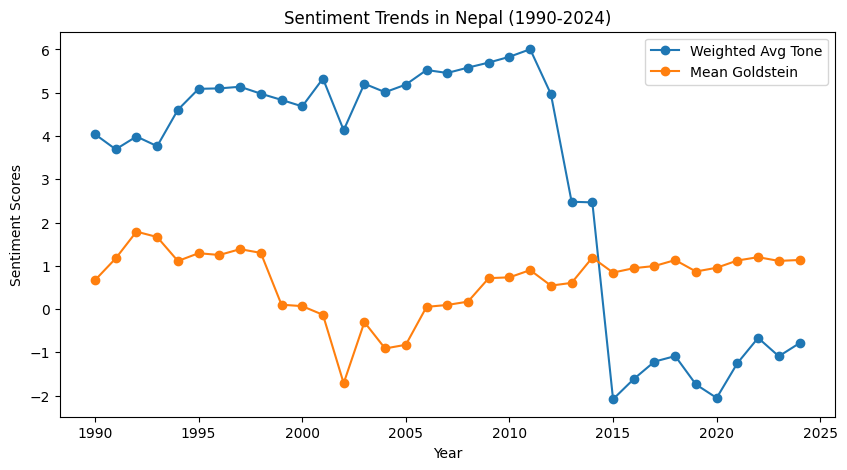

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Weighted_Avg_Tone'], label='Weighted Avg Tone', marker='o')
plt.plot(df.index, df['Mean_Goldstein'], label='Mean Goldstein', marker='o')
plt.xlabel('Year')
plt.ylabel('Sentiment Scores')
plt.title('Sentiment Trends in Nepal (1990-2024)')
plt.legend()

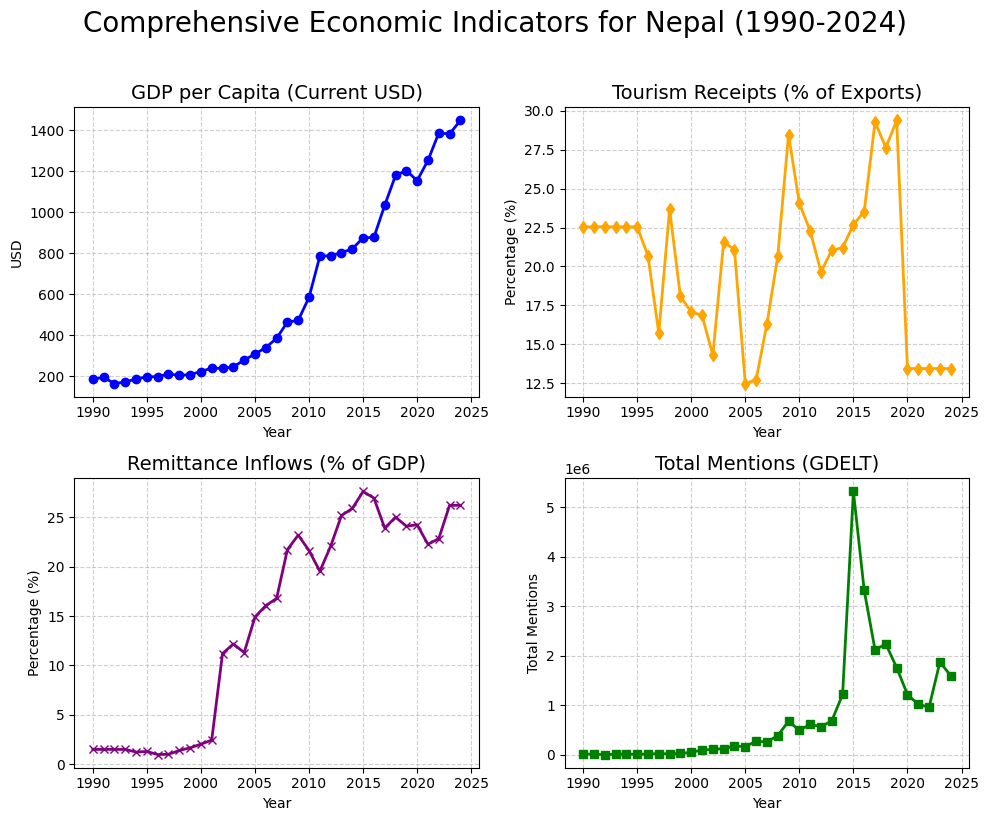

In [38]:
import matplotlib.pyplot as plt

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle('Comprehensive Economic Indicators for Nepal (1990-2024)', fontsize=20, y=1.02)

# 1. GDP per Capita (USD)
axes[0, 0].plot(df.index, df['GDP_per_Capita_USD'], color='blue', marker='o', linewidth=2)
axes[0, 0].set_title('GDP per Capita (Current USD)', fontsize=14)
axes[0, 0].set_ylabel('USD')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Tourism Receipts (% of Exports)
axes[0, 1].plot(df.index, df['Tourism_Receipts_Pct_Exports'], color='orange', marker='d', linewidth=2)
axes[0, 1].set_title('Tourism Receipts (% of Exports)', fontsize=14)
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 3. Remittance Inflows (% of GDP)
axes[1, 0].plot(df.index, df['Remittances_Pct_GDP'], color='purple', marker='x', linewidth=2)
axes[1, 0].set_title('Remittance Inflows (% of GDP)', fontsize=14)
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# 4. Total Mentions (GDELT)
axes[1, 1].plot(df.index, df['Total_Mentions'], color='green', marker='s', linewidth=2)
axes[1, 1].set_title('Total Mentions (GDELT)', fontsize=14)
axes[1, 1].set_ylabel('Total Mentions')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Shared X-label for the bottom plots
for ax in axes.flat:
    ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig('nepal_economic_subplots.png', bbox_inches='tight')
plt.show()

In [39]:
df_stable = df.pct_change().dropna()

epsilon = 1e-6 
mask = np.isclose(df_stable, 0.0, atol=1e-10)
df_stable[mask] = epsilon

df_stable = df_stable + 0.0

df_stable = df_stable.round(6)

In [40]:
df_stable

,Weighted_Avg_Tone,Mean_Goldstein,Total_Mentions,Event_Count,Remittances_Pct_GDP,Tourism_Receipts_Pct_Exports,GDP_per_Capita_USD
Year,,,,,,,
1991,-0.086366,0.754933,-0.447821,-0.510539,0.000001,0.000001,0.053403
1992,0.080328,0.527368,-0.364203,-0.252237,0.000001,0.000001,-0.156793
1993,-0.055972,-0.069700,0.778407,0.617801,0.000001,0.000001,0.047116
1994,0.223218,-0.332976,0.412235,0.351826,-0.177275,0.000001,0.083637
1995,0.105208,0.162509,-0.348194,-0.159713,0.047640,0.000001,0.056525
1996,0.001998,-0.031880,0.641225,0.408628,-0.243550,-0.082994,0.004948
1997,0.007401,0.107557,0.279239,0.265819,0.029550,-0.240231,0.065450
1998,-0.031109,-0.061786,-0.155981,-0.198585,0.382440,0.507514,-0.031910
1999,-0.028834,-0.922023,0.425587,0.256337,0.192825,-0.237052,0.017415


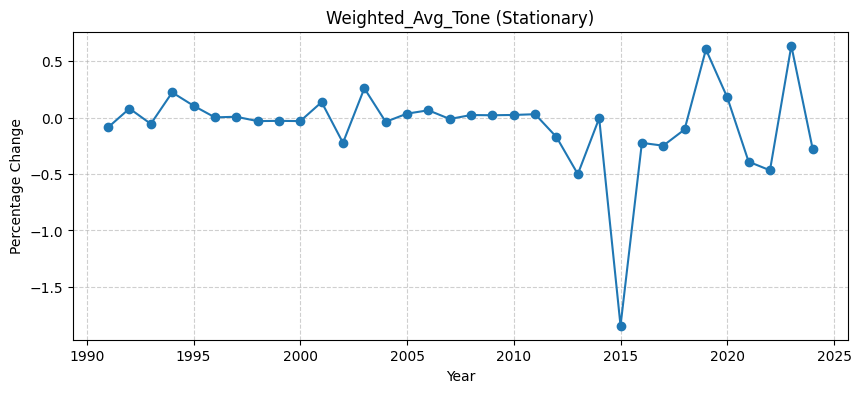

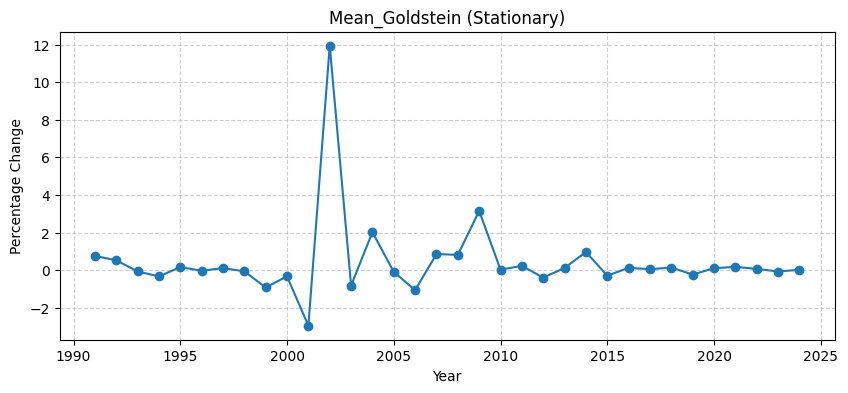

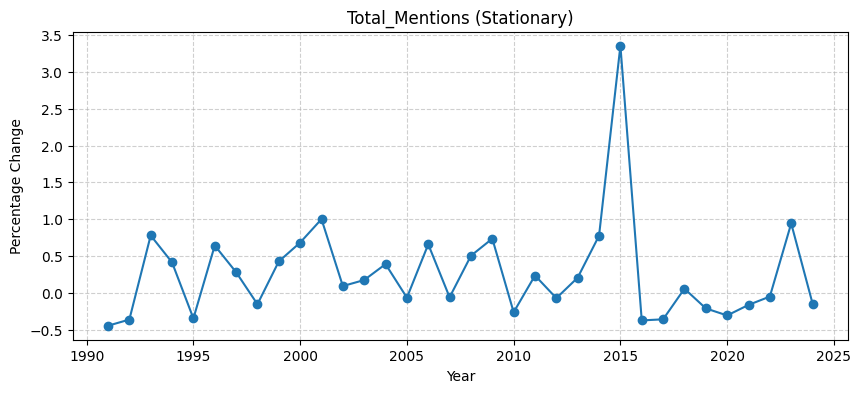

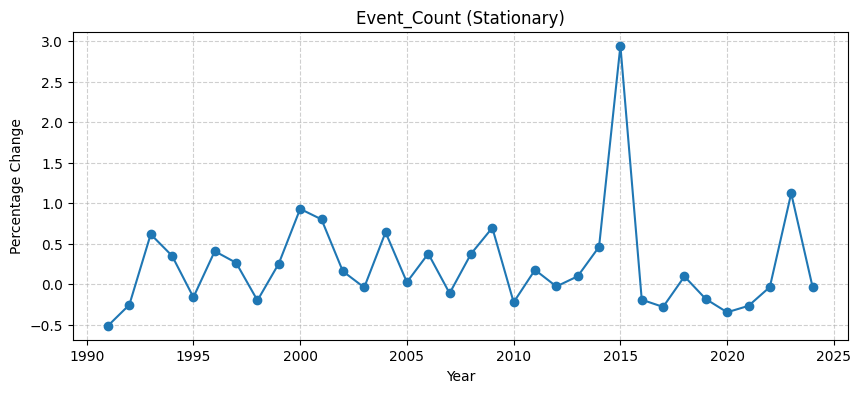

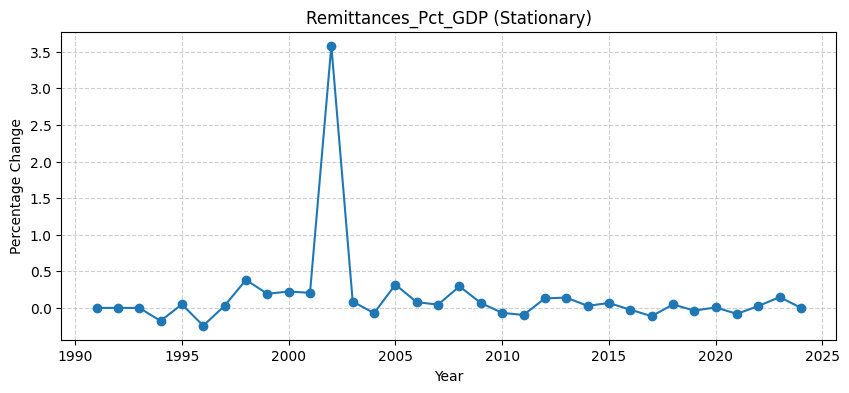

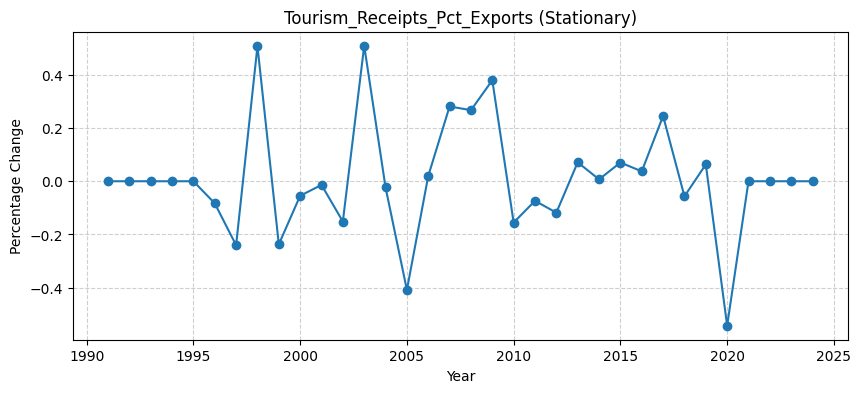

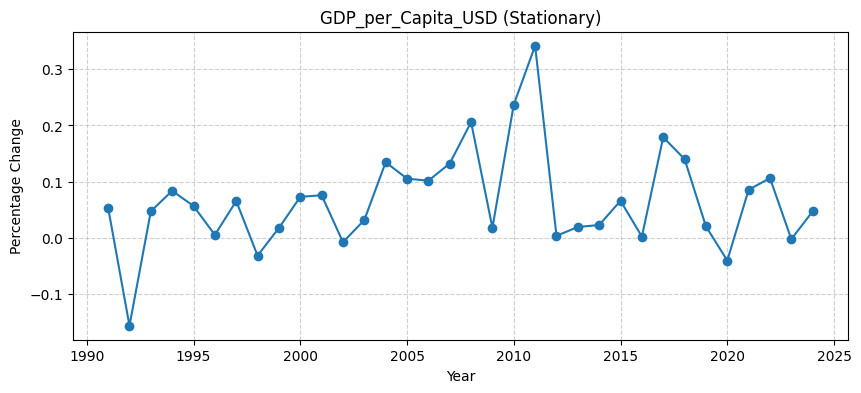

In [41]:
for col in df_stable.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_stable.index, df_stable[col], marker='o')
    plt.title(f'{col} (Stationary)')
    plt.xlabel('Year')
    plt.ylabel('Percentage Change')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [42]:
def check_stationarity(df):
    for col in df.columns:
        result = adfuller(df[col])
        print(f'ADF Statistic for {col}: {result[0]:.4f}')
        print(f'p-value for {col}: {result[1]:.4f}')
        print('---')
        
check_stationarity(df_stable)

ADF Statistic for Weighted_Avg_Tone: -5.5055
p-value for Weighted_Avg_Tone: 0.0000
---
ADF Statistic for Mean_Goldstein: -7.5718
p-value for Mean_Goldstein: 0.0000
---
ADF Statistic for Total_Mentions: -5.6484
p-value for Total_Mentions: 0.0000
---
ADF Statistic for Event_Count: -5.6593
p-value for Event_Count: 0.0000
---
ADF Statistic for Remittances_Pct_GDP: -5.3930
p-value for Remittances_Pct_GDP: 0.0000
---
ADF Statistic for Tourism_Receipts_Pct_Exports: -6.3494
p-value for Tourism_Receipts_Pct_Exports: 0.0000
---
ADF Statistic for GDP_per_Capita_USD: -4.6509
p-value for GDP_per_Capita_USD: 0.0001
---


In [144]:
df_stable

,GDP_per_Capita_USD,Total_Population,Total_Mentions,Event_Count,Remittances_Pct_GDP,Tourism_Receipts_Pct_Exports,Weighted_Avg_Tone,Mean_Goldstein
Year,,,,,,,,
1992,-0.156793,0.002388,-0.364203,-0.252237,-0.000001,0.000001,0.296,0.114
1993,0.047113,-0.000929,0.778407,0.617801,-0.000001,0.000001,-0.223,-0.743
1994,0.083638,-0.002310,0.412235,0.351826,-0.266000,0.000001,0.840,-0.429
1995,0.056526,-0.001059,-0.348194,-0.159713,0.059000,0.000001,0.485,0.734
1996,0.004948,-0.001994,0.641225,0.408628,-0.314000,-1.871000,0.010,-0.221
1997,0.065451,-0.001315,0.279239,0.265819,0.029000,-4.967000,0.038,0.175
1998,-0.031912,-0.001152,-0.155981,-0.198585,0.384000,7.973000,-0.160,-0.219
1999,0.017418,-0.001064,0.425587,0.256337,0.268000,-5.614000,-0.143,-1.113
2000,0.072769,-0.001322,0.681701,0.930628,0.371000,-0.987000,-0.151,1.165


In [46]:
# 3. Time Series Split for Validation 
df_stable = df_stable.astype('float64')

train = df_stable[df_stable.index <= 2022]
val   = df_stable[df_stable.index == 2023]
test  = df_stable[df_stable.index == 2024]

In [47]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1991 to 2022
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Weighted_Avg_Tone             32 non-null     float64
 1   Mean_Goldstein                32 non-null     float64
 2   Total_Mentions                32 non-null     float64
 3   Event_Count                   32 non-null     float64
 4   Remittances_Pct_GDP           32 non-null     float64
 5   Tourism_Receipts_Pct_Exports  32 non-null     float64
 6   GDP_per_Capita_USD            32 non-null     float64
dtypes: float64(7)
memory usage: 2.0 KB


In [48]:
model = VAR(train)

c:\Users\manis\anaconda3\envs\onlyusethis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [49]:
order_selection = model.select_order(maxlags=2)
selected_lag = order_selection.aic
print(f"Optimal Lag chosen by AIC: {selected_lag}")

Optimal Lag chosen by AIC: 2


In [50]:
order_selection.summary()

,AIC,BIC,FPE,HQIC
0,-15.69,-15.37*,1.530e-07*,-15.59*
1,-14.88,-12.27,3.766e-07,-14.05
2,-15.70*,-10.80,3.025e-07,-14.13


In [51]:
var_result = model.fit(1)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 15, Mar, 2026
Time:                     21:22:43
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -12.1750
Nobs:                     31.0000    HQIC:                  -13.9210
Log likelihood:          -23.0461    FPE:                4.20499e-07
AIC:                     -14.7654    Det(Omega_mle):     8.43032e-08
--------------------------------------------------------------------
Results for equation Weighted_Avg_Tone
                                     coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------------
const                                  -0.120345         0.096547           -1.246           0.213
L1.Weighted_Avg_Tone                    0.087384         0.257948          

In [52]:
is_stable = var_result.is_stable(verbose=True)
print(f"Is the model stable? {is_stable}")

Eigenvalues of VAR(1) rep
0.5445451972105121
0.5377544619075622
0.4105142071419264
0.4105142071419264
0.245002092185278
0.245002092185278
0.25225212832964633
Is the model stable? True


In [66]:
def untransform_forecast(forecast_df, last_actual_row):

    untransformed_results = []
    current_base = last_actual_row.copy()
    
    for index, row in forecast_df.iterrows():
        new_values = current_base * (1 + row)
        untransformed_results.append(new_values)
        
        current_base = new_values
        
    return pd.DataFrame(untransformed_results, index=forecast_df.index)

In [67]:
forecast_steps = var_result.forecast(y=train.values[-1:], steps=1)
df_forecast_2023 = pd.DataFrame(forecast_steps, columns=train.columns, index=[2023])
df_untransformed_2023 = untransform_forecast(df_forecast_2023, df.loc[2022])

In [68]:
actual_gdp_2023 = df.loc[2023, 'GDP_per_Capita_USD']
predicted_gdp_2023 = df_untransformed_2023.loc[2023, 'GDP_per_Capita_USD']

error_val = abs(actual_gdp_2023 - predicted_gdp_2023)
error_pct = (error_val / actual_gdp_2023) * 100

print(f"--- 2023 Validation Results ---")
print(f"Actual GDP 2023:    ${actual_gdp_2023:,.2f}")
print(f"Predicted GDP 2023: ${predicted_gdp_2023:,.2f}")
print(f"Absolute Error:     ${error_val:,.2f}")
print(f"Percentage Error:    {error_pct:.2f}%")

--- 2023 Validation Results ---
Actual GDP 2023:    $1,382.33
Predicted GDP 2023: $1,490.81
Absolute Error:     $108.48
Percentage Error:    7.85%


In [69]:
forecast_values = var_result.forecast(y=train.values[-1:], steps=2)
df_forecast_steps = pd.DataFrame(forecast_values, 
                                columns=train.columns, 
                                index=[2023, 2024])

df_final_results = untransform_forecast(df_forecast_steps, df.loc[2022])

actual_2023 = df.loc[2023, 'GDP_per_Capita_USD']
actual_2024 = df.loc[2024, 'GDP_per_Capita_USD']

pred_2023 = df_final_results.loc[2023, 'GDP_per_Capita_USD']
pred_2024 = df_final_results.loc[2024, 'GDP_per_Capita_USD']

error_pct_2023 = abs(actual_2023 - pred_2023) / actual_2023 * 100
error_pct_2024 = abs(actual_2024 - pred_2024) / actual_2024 * 100

print(f"Validation & Test Results ")
print(f"2023 Actual: ${actual_2023:,.2f} | Predicted: ${pred_2023:,.2f} | Error: {error_pct_2023:.2f}%")
print(f"2024 Actual: ${actual_2024:,.2f} | Predicted: ${pred_2024:,.2f} | Error: {error_pct_2024:.2f}%")

print(f"\n Final Performance Metrics ")
print(f"Mean Absolute Percentage Error (MAPE): {((error_pct_2023 + error_pct_2024) / 2):.2f}%")

Validation & Test Results 
2023 Actual: $1,382.33 | Predicted: $1,490.81 | Error: 7.85%
2024 Actual: $1,447.31 | Predicted: $1,607.97 | Error: 11.10%

 Final Performance Metrics 
Mean Absolute Percentage Error (MAPE): 9.47%


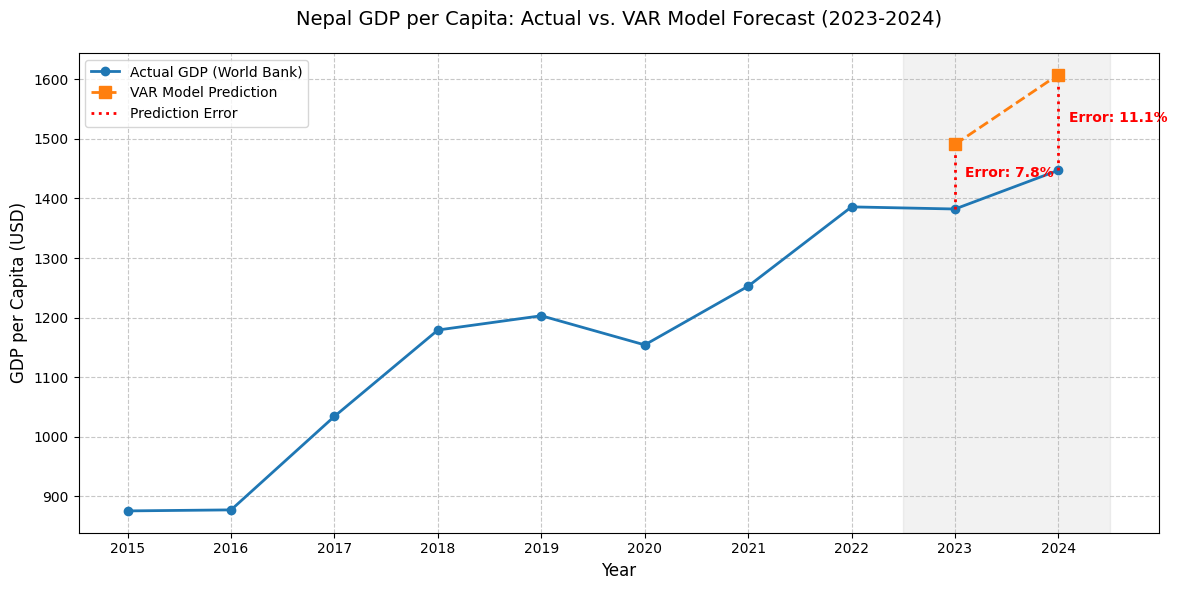

In [83]:
plot_start_year = 2015 
years_historical = df.index[(df.index >= plot_start_year) & (df.index <= 2024)]
actual_values = df.loc[years_historical, 'GDP_per_Capita_USD']

pred_years = [2023, 2024]
predicted_values = [pred_2023, pred_2024]
actual_test_values = [actual_2023, actual_2024]

plt.figure(figsize=(12, 6))

plt.plot(years_historical, actual_values, label='Actual GDP (World Bank)', 
        color='#1f77b4', marker='o', linewidth=2, zorder=2)

plt.plot(pred_years, predicted_values, label='VAR Model Prediction', 
        color='#ff7f0e', linestyle='--', marker='s', markersize=8, linewidth=2, zorder=3)

for i, year in enumerate(pred_years):
    plt.vlines(x=year, ymin=min(actual_test_values[i], predicted_values[i]), 
            ymax=max(actual_test_values[i], predicted_values[i]), 
            color='red', linestyle=':', linewidth=2, label='Prediction Error' if i == 0 else "")
    
    error = error_pct_2023 if year == 2023 else error_pct_2024
    plt.text(year + 0.1, (actual_test_values[i] + predicted_values[i])/2, 
            f'Error: {error:.1f}%', color='red', fontweight='bold')

plt.title("Nepal GDP per Capita: Actual vs. VAR Model Forecast (2023-2024)", fontsize=14, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("GDP per Capita (USD)", fontsize=12)
plt.xticks(list(range(plot_start_year, 2025)))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')

plt.axvspan(2022.5, 2024.5, color='gray', alpha=0.1, label="Test Period")

plt.tight_layout()
plt.show()

In [71]:
# Equation: Does Tone predict GDP?
granger_test = var_result.test_causality('GDP_per_Capita_USD', ['Weighted_Avg_Tone'], kind='f')

print(f"--- Granger Causality Results ---")
print(f"Statistic: {granger_test.test_statistic:.4f}")
print(f"P-Value:   {granger_test.pvalue:.4f}")

# Interpretation logic
if granger_test.pvalue < 0.05:
    print("Conclusion: Weighted_Avg_Tone GRANGER-CAUSES GDP_per_Capita_USD (Significant)")
else:
    print("Conclusion: No strong Granger-causal link found at the 0.05 level.")

--- Granger Causality Results ---
Statistic: 0.0232
P-Value:   0.8792
Conclusion: No strong Granger-causal link found at the 0.05 level.


In [ ]:
# Inverse test: Does GDP predict Tone?
granger_inverse = var_result.test_causality('Weighted_Avg_Tone', ['GDP_per_Capita_USD'], kind='f')
print(f"Inverse Granger P-Value: {granger_inverse.pvalue:.4f}")

if granger_inverse.pvalue < 0.05:
    print("Conclusion: GDP_per_Capita_USD GRANGER-CAUSES Weighted_Avg_Tone (Significant)")
else:
    print("Conclusion: No strong Granger-causal link found in the inverse direction at the 0.05 level.")

Inverse Granger P-Value: 0.4125
Conclusion: No strong Granger-causal link found in the inverse direction at the 0.05 level.


<Figure size 400x400 with 0 Axes>

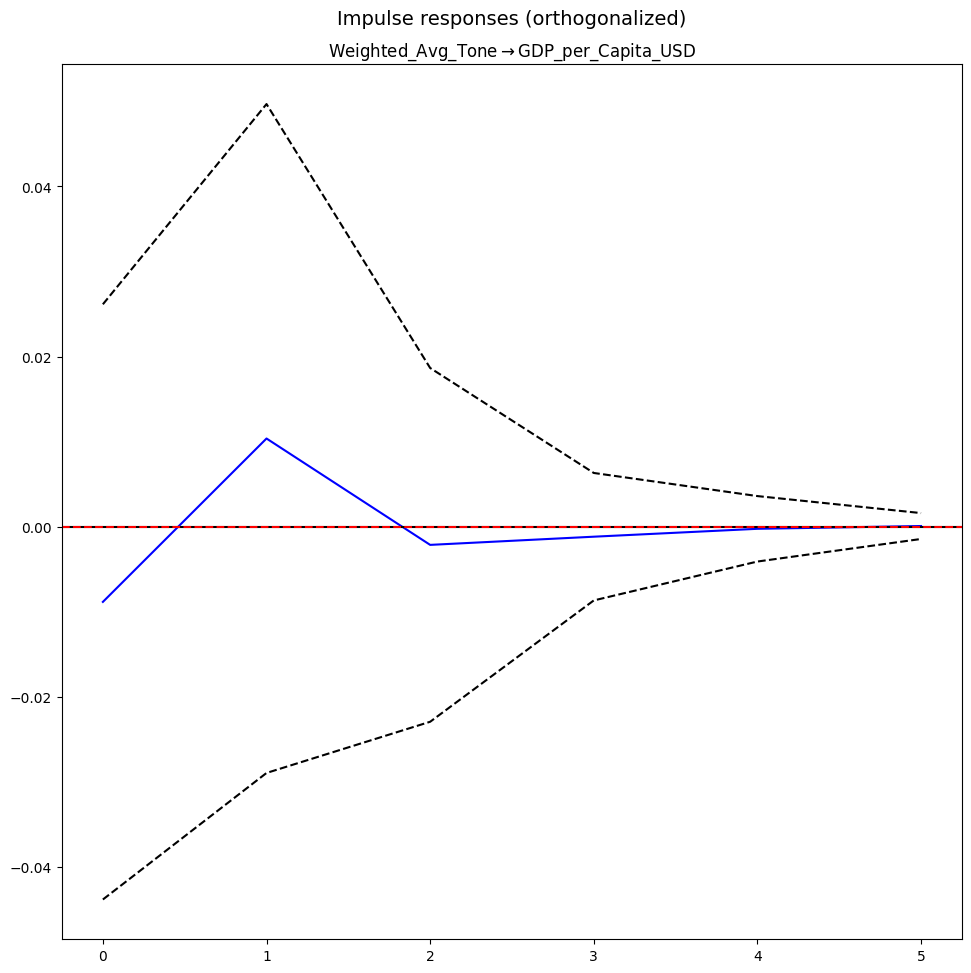

In [79]:
# Create the IRF object
irf = var_result.irf(5)
plt.figure(figsize=(4, 4))
irf.plot(impulse='Weighted_Avg_Tone', response='GDP_per_Capita_USD', orth=True)
plt.axhline(0, color='red', linestyle='--') 
plt.show()
